# Optimization & Initialization

As the number of layers increases, the importance of **initialization** becomes more important as the we need a **stable gradient flow** through the network, otherwise, we might encounter **gradient vanishing or exploding**.


## Different initialization techniques

### Import standard libraries

In [2]:
# Standard libraries
import os
import json
import math
import numpy as np
import copy

# For plotting
import matplotlib.pyplot as plt
from matplotlib import cm
%matplotlib inline
import IPython
from matplotlib_inline.backend_inline import set_matplotlib_formats
IPython.display.set_matplotlib_formats = set_matplotlib_formats
set_matplotlib_formats('svg', 'pdf')
import seaborn as sns
sns.set()

# Progress bar
from tqdm.notebook import tqdm

# Pytorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim

In [3]:
DATASET_PATH = './data'
CHECKPOINT_PATH = './saved_models'

def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)
        torch.use_deterministic_algorithms(True)

set_seed(42)

device = torch.device('mps') if torch.backends.mps.is_available() else torch.device('cpu')
print(device)

mps


In [4]:
import urllib.request
from urllib.error import HTTPError
base_url = "https://raw.githubusercontent.com/phlippe/saved_models/main/tutorial4/"
pretrained_files = ["FashionMNIST_SGD.config",    "FashionMNIST_SGD_results.json",    "FashionMNIST_SGD.tar",
                    "FashionMNIST_SGDMom.config", "FashionMNIST_SGDMom_results.json", "FashionMNIST_SGDMom.tar",
                    "FashionMNIST_Adam.config",   "FashionMNIST_Adam_results.json",   "FashionMNIST_Adam.tar"]

os.makedirs(CHECKPOINT_PATH, exist_ok=True)

for file_name in pretrained_files:
    file_path = os.path.join(CHECKPOINT_PATH, file_name)
    if not os.path.isfile(file_path):
        file_url = base_url + file_name
        print(f"Downloading {file_url} ...")
        try:
            urllib.request.urlretrieve(file_url, file_path)
        except HTTPError as e:
            print(f"Failed to download {file_url}. Error: {e}")

### Preparation

Normalize the input pixels into a mean of 0 and a standard deviation of 1.

In [5]:
# Loading the FashionMNIST dataset
from torchvision.datasets import FashionMNIST
from torchvision import transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2861,), (0.3530,))
])

train_dataset = FashionMNIST(root=DATASET_PATH, train=True, transform=transform, download=True)
train_set, val_set = torch.utils.data.random_split(train_dataset, [50000, 10000])
test_set = FashionMNIST(root=DATASET_PATH, train=False, transform=transform, download=True)

train_loader = data.DataLoader(train_set, batch_size=1024, shuffle=True, drop_last=False)
val_loader = data.DataLoader(val_set, batch_size=1024, shuffle=False, drop_last=False)
test_loader = data.DataLoader(test_set, batch_size=1024, shuffle=True, drop_last=False)

For most classification tasks, both normalizing techniques(between -1 and 1 or mean 0 and stddev 1) have shown to work well.

We can calculate the normalization parameters by determining the mean and standard deviation on the original images.

In [6]:
print("Mean", (train_dataset.data.float() / 255.0).mean().item())
print("Std", (train_dataset.data.float() / 255.0).std().item())

Mean 0.28604060411453247
Std 0.3530242443084717


We can **verify** the **transformation** by looking at the **statistics** of a single **batch**.

In [7]:
imgs, _ = next(iter(train_loader))
print(f"Mean: {imgs.mean().item():5.3f}")
print(f"Std: {imgs.std().item():5.3f}")
print(f"Maximum: {imgs.max().item():5.3f}")
print(f"Minimum: {imgs.min().item():5.3f}")


Mean: 0.020
Std: 1.011
Maximum: 2.022
Minimum: -0.810


Note that the maximum and minimum value are not 1 and -1 but shifted towards the positive values. This is because FashionMNIST contains a lot of **black pixels**.

In [34]:
# Create the linear neural network
class BaseNetwork(nn.Module):
    def __init__(self, act_fn, input_size=784, num_classes=10, hidden_sizes=[512, 256, 256, 128]):
        super().__init__()

        layers = []
        layer_sizes = [input_size] + hidden_sizes
        for layer_index in range(1, len(layer_sizes)):
            layers += [nn.Linear(layer_sizes[layer_index-1], layer_sizes[layer_index]), act_fn]
        layers += [nn.Linear(layer_sizes[-1], num_classes)]
        self.layers = nn.ModuleList(layers)
        
        self.config = {
            "act_fn": act_fn.__class__.__name__,
            "input_size": input_size,
            "num_classes": num_classes,
            "hidden_sizes": hidden_sizes,
        }
    
    def forward(self, x):
        x = x.view(x.size(0), -1)
        for l in self.layers:
            x = l(x)
        return x

We define the `Identity` function which would significantly limit the models' expressiveness.

In [35]:
class Identity(nn.Module):
    def forward(self, x):
        return x

act_fn_by_name = {
    "tanh": nn.Tanh,
    "relu": nn.ReLU,
    "identity": Identity,
}

Define plotting functions for discussing the results.


In [36]:
def plot_dists(val_dict, color="C0", xlabel=None, stat="count", use_kde=True):
    columns = len(val_dict)
    fig, ax = plt.subplots(1, columns, figsize=(columns*3, 2.5))
    fig_index = 0
    for key in sorted(val_dict.keys()):
        key_ax = ax[fig_index%columns]
        sns.histplot(val_dict[key], ax=key_ax, color=color, bins=50, stat=stat,
                     kde=use_kde and ((val_dict[key].max()-val_dict[key].min())>1e-8)) # Only plot kde if there is variance
        key_ax.set_title(f"{key} " + (r"(%i $\to$ %i)" % (val_dict[key].shape[1], val_dict[key].shape[0]) if len(val_dict[key].shape)>1 else ""))
        if xlabel is not None:
            key_ax.set_xlabel(xlabel)
        fig_index += 1
    fig.subplots_adjust(wspace=0.4)
    return fig

def visualize_weight_distribution(model, color="C0"):
    weights = {}
    for name, param in model.named_parameters():
        if name.endswith(".bias"):
            continue
        key_name = f"Layer {name.split('.')[1]}"
        weights[key_name] = param.detach().view(-1).cpu().numpy()

    ## Plotting
    fig = plot_dists(weights, color=color, xlabel="Weight vals")
    fig.suptitle("Weight distribution", fontsize=14, y=1.05)
    plt.show()
    plt.close()

def visualize_gradients(model, color="C0", print_variance=False):
    """
    Inputs:
        net - Object of class BaseNetwork
        color - Color in which we want to visualize the histogram (for easier separation of activation functions)
    """
    model.eval()
    small_loader = data.DataLoader(train_set, batch_size=1024, shuffle=False)
    imgs, labels = next(iter(small_loader))
    imgs, labels = imgs.to(device), labels.to(device)

    # Pass one batch through the network, and calculate the gradients for the weights
    model.zero_grad()
    preds = model(imgs)
    loss = F.cross_entropy(preds, labels) # Same as nn.CrossEntropyLoss, but as a function instead of module
    loss.backward()
    # We limit our visualization to the weight parameters and exclude the bias to reduce the number of plots
    grads = {name: params.grad.view(-1).cpu().clone().numpy() for name, params in model.named_parameters() if "weight" in name}
    model.zero_grad()

    ## Plotting
    fig = plot_dists(grads, color=color, xlabel="Grad magnitude")
    fig.suptitle("Gradient distribution", fontsize=14, y=1.05)
    plt.show()
    plt.close()

    if print_variance:
        for key in sorted(grads.keys()):
            print(f"{key} - Variance: {np.var(grads[key])}")

def visualize_activations(model, color="C0", print_variance=False):
    model.eval()
    small_loader = data.DataLoader(train_set, batch_size=1024, shuffle=False)
    imgs, labels = next(iter(small_loader))
    imgs, labels = imgs.to(device), labels.to(device)

    # Pass one batch through the network, and calculate the gradients for the weights
    feats = imgs.view(imgs.shape[0], -1)
    activations = {}
    with torch.no_grad():
        for layer_index, layer in enumerate(model.layers):
            feats = layer(feats)
            if isinstance(layer, nn.Linear):
                activations[f"Layer {layer_index}"] = feats.view(-1).detach().cpu().numpy()

    ## Plotting
    fig = plot_dists(activations, color=color, stat="density", xlabel="Activation vals")
    fig.suptitle("Activation distribution", fontsize=14, y=1.05)
    plt.show()
    plt.close()

    if print_variance:
        for key in sorted(activations.keys()):
            print(f"{key} - Variance: {np.var(activations[key])}")

### Initialization

When taking about initialization, several properties should be noted:
1. The **variance** of the input should be propagated through the model to the last layer, so that the **standard deviation** for the output neurons are **similar**. If the variance would vanish as the model is deepened, it becomes much harder to optimize the model as the input to the next layer is basically a single constant value. Similarly, if the variance increases, it likely to explode as the model is deepened.
2. The **gradient distribution** with **equal variance** across the layers. If the first layer receives much smaller gradients than the last layer, it would be difficult to choose a appropriate learning rate.

First, for network with no activation function(Identity function), the variance of the output is equal to the variance of the input.

In [37]:
model = BaseNetwork(act_fn=Identity()).to(device)

#### Constant initialization

Initialize all the weights to the same constant value.

Intuitively, setting all the weights to 0 is not good as the gradients would be zero.

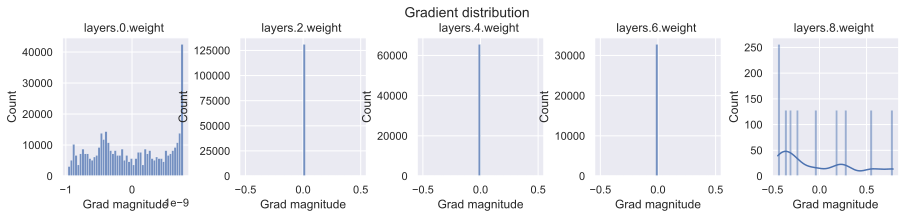

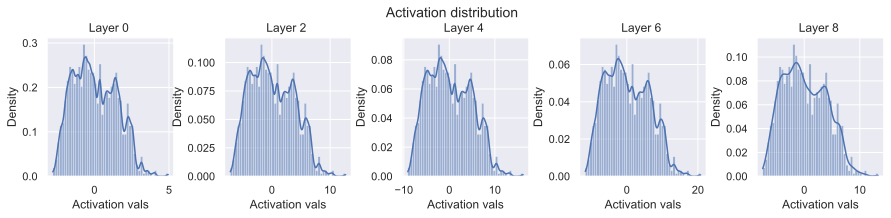

Layer 0 - Variance: 2.0582754611968994
Layer 2 - Variance: 13.489115715026855
Layer 4 - Variance: 22.100555419921875
Layer 6 - Variance: 36.209537506103516
Layer 8 - Variance: 14.83142375946045


In [38]:
def const_init(model, c=0.0):
    for name, param in model.named_parameters():
        param.data.fill_(c)

const_init(model, c=0.005)
visualize_gradients(model)
visualize_activations(model, print_variance=True)

With the constant initialization(positive value), only the first and last layer have diverse gradient distributions while the other layers have the same gradient for all weights(close to 0 but not exactly 0).

Having the **same gradient for parameters** that have been **initialized with the same values** means that we will **always have the same value for those parameters**. This would make the layer **useless** and **reduce the effective** number of parameters to 1.

We **cannot** use this initialization method to train neural networks.

#### Constant variance

What about initializing the parameters by randomly sampling from a Gaussian distribution?

The most **effective** way is to **choose one variance** to that is used **for all layers** in the network.

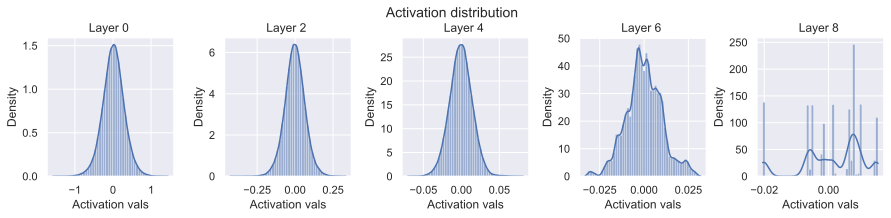

Layer 0 - Variance: 0.08043354749679565
Layer 2 - Variance: 0.004367820918560028
Layer 4 - Variance: 0.0002187194040743634
Layer 6 - Variance: 0.00010234453657176346
Layer 8 - Variance: 9.366330777993426e-05


In [39]:
def var_init(model, std=0.01):
    for name, param in model.named_parameters():
        param.data.normal_(std=std)

var_init(model, std=0.01)
visualize_activations(model, print_variance=True)

The **variance** of activations becomes **smaller** and even vanish in the last layer.

What about using a higher standard deviation?

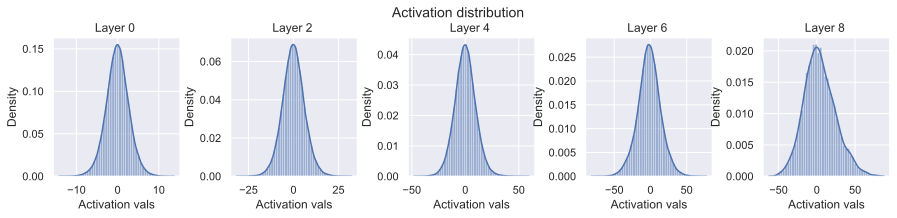

Layer 0 - Variance: 7.685174942016602
Layer 2 - Variance: 37.88572311401367
Layer 4 - Variance: 96.24340057373047
Layer 6 - Variance: 248.73255920410156
Layer 8 - Variance: 427.0025329589844


In [40]:
var_init(model, std=0.1)
visualize_activations(model, print_variance=True)

With a higher standard deviation, the **variance** of activations are likely to explode.

You can adjust with different standard deviation and might note that it is **ineffective** to find a appropriate value. It is also **not recommended** to do so.

#### How to find appropriate initialization values

In order to find appropriate initialization values, we state two **requirements**:
1. The **mean** of the activations should be **zero**.
2. The **variance** of the activations should stay the **same** across every layer.

<math xmlns="http://www.w3.org/1998/Math/MathML" display="block">
  <mtable displaystyle="true" columnalign="right" columnspacing="0em" rowspacing="3pt">
    <mtr>
      <mtd>
        <mtable displaystyle="true" columnalign="right left" columnspacing="0em" rowspacing="3pt">
          <mtr>
            <mtd>
              <msub>
                <mi>y</mi>
                <mi>i</mi>
              </msub>
            </mtd>
            <mtd>
              <mi></mi>
              <mo>=</mo>
              <munder>
                <mo data-mjx-texclass="OP">&#x2211;</mo>
                <mrow data-mjx-texclass="ORD">
                  <mi>j</mi>
                </mrow>
              </munder>
              <msub>
                <mi>w</mi>
                <mrow data-mjx-texclass="ORD">
                  <mi>i</mi>
                  <mi>j</mi>
                </mrow>
              </msub>
              <msub>
                <mi>x</mi>
                <mrow data-mjx-texclass="ORD">
                  <mi>j</mi>
                </mrow>
              </msub>
              <mspace width="10mm"></mspace>
              <mtext>Calculation of a single output neuron without bias</mtext>
            </mtd>
          </mtr>
          <mtr>
            <mtd>
              <mtext>Var</mtext>
              <mo stretchy="false">(</mo>
              <msub>
                <mi>y</mi>
                <mi>i</mi>
              </msub>
              <mo stretchy="false">)</mo>
              <mo>=</mo>
              <msubsup>
                <mi>&#x3C3;</mi>
                <mi>x</mi>
                <mrow data-mjx-texclass="ORD">
                  <mn>2</mn>
                </mrow>
              </msubsup>
            </mtd>
            <mtd>
              <mi></mi>
              <mo>=</mo>
              <mtext>Var</mtext>
              <mrow data-mjx-texclass="INNER">
                <mo data-mjx-texclass="OPEN">(</mo>
                <munder>
                  <mo data-mjx-texclass="OP">&#x2211;</mo>
                  <mrow data-mjx-texclass="ORD">
                    <mi>j</mi>
                  </mrow>
                </munder>
                <msub>
                  <mi>w</mi>
                  <mrow data-mjx-texclass="ORD">
                    <mi>i</mi>
                    <mi>j</mi>
                  </mrow>
                </msub>
                <msub>
                  <mi>x</mi>
                  <mrow data-mjx-texclass="ORD">
                    <mi>j</mi>
                  </mrow>
                </msub>
                <mo data-mjx-texclass="CLOSE">)</mo>
              </mrow>
            </mtd>
          </mtr>
          <mtr>
            <mtd></mtd>
            <mtd>
              <mi></mi>
              <mo>=</mo>
              <munder>
                <mo data-mjx-texclass="OP">&#x2211;</mo>
                <mrow data-mjx-texclass="ORD">
                  <mi>j</mi>
                </mrow>
              </munder>
              <mtext>Var</mtext>
              <mo stretchy="false">(</mo>
              <msub>
                <mi>w</mi>
                <mrow data-mjx-texclass="ORD">
                  <mi>i</mi>
                  <mi>j</mi>
                </mrow>
              </msub>
              <msub>
                <mi>x</mi>
                <mrow data-mjx-texclass="ORD">
                  <mi>j</mi>
                </mrow>
              </msub>
              <mo stretchy="false">)</mo>
              <mspace width="10mm"></mspace>
              <mtext>Inputs and weights are independent of each other</mtext>
            </mtd>
          </mtr>
          <mtr>
            <mtd></mtd>
            <mtd>
              <mi></mi>
              <mo>=</mo>
              <munder>
                <mo data-mjx-texclass="OP">&#x2211;</mo>
                <mrow data-mjx-texclass="ORD">
                  <mi>j</mi>
                </mrow>
              </munder>
              <mtext>Var</mtext>
              <mo stretchy="false">(</mo>
              <msub>
                <mi>w</mi>
                <mrow data-mjx-texclass="ORD">
                  <mi>i</mi>
                  <mi>j</mi>
                </mrow>
              </msub>
              <mo stretchy="false">)</mo>
              <mo>&#x22C5;</mo>
              <mtext>Var</mtext>
              <mo stretchy="false">(</mo>
              <msub>
                <mi>x</mi>
                <mrow data-mjx-texclass="ORD">
                  <mi>j</mi>
                </mrow>
              </msub>
              <mo stretchy="false">)</mo>
              <mspace width="10mm"></mspace>
              <mtext>Variance rule (see above) with expectations being zero</mtext>
            </mtd>
          </mtr>
          <mtr>
            <mtd></mtd>
            <mtd>
              <mi></mi>
              <mo>=</mo>
              <msub>
                <mi>d</mi>
                <mi>x</mi>
              </msub>
              <mo>&#x22C5;</mo>
              <mtext>Var</mtext>
              <mo stretchy="false">(</mo>
              <msub>
                <mi>w</mi>
                <mrow data-mjx-texclass="ORD">
                  <mi>i</mi>
                  <mi>j</mi>
                </mrow>
              </msub>
              <mo stretchy="false">)</mo>
              <mo>&#x22C5;</mo>
              <mtext>Var</mtext>
              <mo stretchy="false">(</mo>
              <msub>
                <mi>x</mi>
                <mrow data-mjx-texclass="ORD">
                  <mi>j</mi>
                </mrow>
              </msub>
              <mo stretchy="false">)</mo>
              <mspace width="10mm"></mspace>
              <mrow>
                <mtext>Variance equal for all&#xA0;</mtext>
                <mrow data-mjx-texclass="ORD">
                  <msub>
                    <mi>d</mi>
                    <mi>x</mi>
                  </msub>
                </mrow>
                <mtext>&#xA0;elements</mtext>
              </mrow>
            </mtd>
          </mtr>
          <mtr>
            <mtd></mtd>
            <mtd>
              <mi></mi>
              <mo>=</mo>
              <msubsup>
                <mi>&#x3C3;</mi>
                <mi>x</mi>
                <mrow data-mjx-texclass="ORD">
                  <mn>2</mn>
                </mrow>
              </msubsup>
              <mo>&#x22C5;</mo>
              <msub>
                <mi>d</mi>
                <mi>x</mi>
              </msub>
              <mo>&#x22C5;</mo>
              <mtext>Var</mtext>
              <mo stretchy="false">(</mo>
              <msub>
                <mi>w</mi>
                <mrow data-mjx-texclass="ORD">
                  <mi>i</mi>
                  <mi>j</mi>
                </mrow>
              </msub>
              <mo stretchy="false">)</mo>
            </mtd>
          </mtr>
          <mtr>
            <mtd>
              <mo stretchy="false">&#x21D2;</mo>
              <mtext>Var</mtext>
              <mo stretchy="false">(</mo>
              <msub>
                <mi>w</mi>
                <mrow data-mjx-texclass="ORD">
                  <mi>i</mi>
                  <mi>j</mi>
                </mrow>
              </msub>
              <mo stretchy="false">)</mo>
              <mo>=</mo>
              <msubsup>
                <mi>&#x3C3;</mi>
                <mrow data-mjx-texclass="ORD">
                  <mi>W</mi>
                </mrow>
                <mn>2</mn>
              </msubsup>
            </mtd>
            <mtd>
              <mi></mi>
              <mo>=</mo>
              <mfrac>
                <mn>1</mn>
                <msub>
                  <mi>d</mi>
                  <mi>x</mi>
                </msub>
              </mfrac>
            </mtd>
          </mtr>
        </mtable>
      </mtd>
    </mtr>
  </mtable>
</math>

Thus, we should initialize the weight distribution with a variance of the inverse of the input dimension 
<math xmlns="http://www.w3.org/1998/Math/MathML">
  <msub>
    <mi>d</mi>
    <mi>x</mi>
  </msub>
</math>

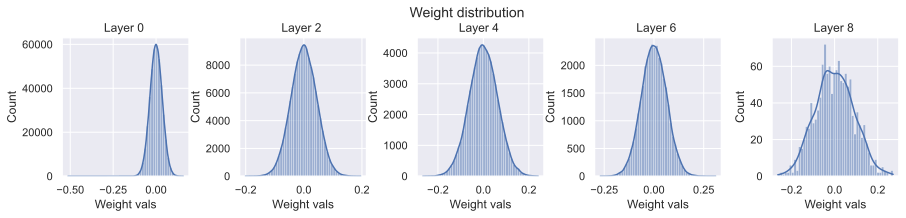

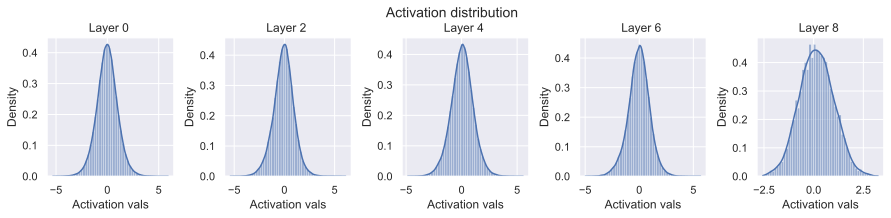

Layer 0 - Variance: 1.0281517505645752
Layer 2 - Variance: 1.0185929536819458
Layer 4 - Variance: 0.9918085932731628
Layer 6 - Variance: 0.9741131663322449
Layer 8 - Variance: 0.7522444725036621


In [41]:
def equal_var_init(model):
    for name, param in model.named_parameters():
        if name.endswith(".bias"):
            param.data.fill_(0)
        else:
            param.data.normal_(std=1.0/math.sqrt(param.shape[1]))

equal_var_init(model)
visualize_weight_distribution(model)
visualize_activations(model, print_variance=True)

As expected, the **variance** stays **constant** across layers. 

Note: It **doesn't require** the initialization from a **normal distribution** but allows any other distribution with a mean of 0 and a variance of 1/
<math xmlns="http://www.w3.org/1998/Math/MathML">
  <msub>
    <mi>d</mi>
    <mi>x</mi>
  </msub>
</math>

We often see a **uniform distribution** is used for initialization. A small **benefit** of using uniform distribution than normal distribution is that we can **exclude of initializing very large or small weights**.


Besides the variance of activation function, we also want the **variance of gradients** to be **stable** as well. This ensures a **stable optimization** process.

Follows the above deduction, we should initialize layers with **1/<math xmlns="http://www.w3.org/1998/Math/MathML">
  <msub>
    <mi>d</mi>
    <mi>y</mi>
  </msub>
</math>**
where 
<math xmlns="http://www.w3.org/1998/Math/MathML">
  <msub>
    <mi>d</mi>
    <mi>y</mi>
  </msub>
</math>
is the number of output neurons.

As a compromise between both constraints, Glorot and Bengio proposed to use the **harmonic mean** of both values, which is **Xavier initialization**：

<math xmlns="http://www.w3.org/1998/Math/MathML" display="block">
  <mi>W</mi>
  <mo>&#x223C;</mo>
  <mrow data-mjx-texclass="ORD">
    <mi data-mjx-variant="-tex-calligraphic" mathvariant="script">N</mi>
  </mrow>
  <mrow data-mjx-texclass="INNER">
    <mo data-mjx-texclass="OPEN">(</mo>
    <mn>0</mn>
    <mo>,</mo>
    <mfrac>
      <mn>2</mn>
      <mrow>
        <msub>
          <mi>d</mi>
          <mi>x</mi>
        </msub>
        <mo>+</mo>
        <msub>
          <mi>d</mi>
          <mi>y</mi>
        </msub>
      </mrow>
    </mfrac>
    <mo data-mjx-texclass="CLOSE">)</mo>
  </mrow>
</math>

If we use a **uniform distribution**, we would initialize the weights with:

<math xmlns="http://www.w3.org/1998/Math/MathML" display="block">
  <mi>W</mi>
  <mo>&#x223C;</mo>
  <mi>U</mi>
  <mrow data-mjx-texclass="INNER">
    <mo data-mjx-texclass="OPEN">[</mo>
    <mo>&#x2212;</mo>
    <mfrac>
      <msqrt>
        <mn>6</mn>
      </msqrt>
      <msqrt>
        <msub>
          <mi>d</mi>
          <mi>x</mi>
        </msub>
        <mo>+</mo>
        <msub>
          <mi>d</mi>
          <mi>y</mi>
        </msub>
      </msqrt>
    </mfrac>
    <mo>,</mo>
    <mfrac>
      <msqrt>
        <mn>6</mn>
      </msqrt>
      <msqrt>
        <msub>
          <mi>d</mi>
          <mi>x</mi>
        </msub>
        <mo>+</mo>
        <msub>
          <mi>d</mi>
          <mi>y</mi>
        </msub>
      </msqrt>
    </mfrac>
    <mo data-mjx-texclass="CLOSE">]</mo>
  </mrow>
</math>

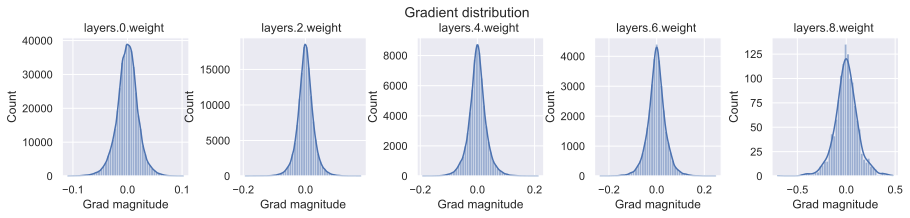

layers.0.weight - Variance: 0.0003898054710589349
layers.2.weight - Variance: 0.0007022242061793804
layers.4.weight - Variance: 0.0010011023841798306
layers.6.weight - Variance: 0.001473061041906476
layers.8.weight - Variance: 0.014630650170147419


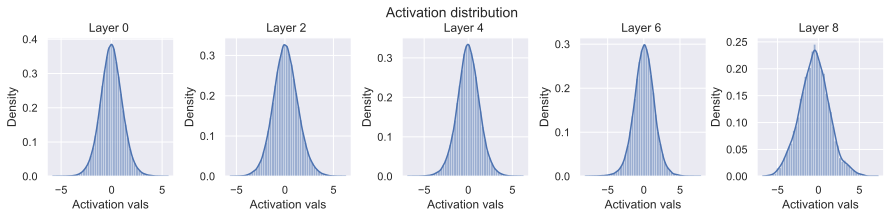

Layer 0 - Variance: 1.2209731340408325
Layer 2 - Variance: 1.658009648323059
Layer 4 - Variance: 1.6508539915084839
Layer 6 - Variance: 2.103919506072998
Layer 8 - Variance: 3.3370437622070312


In [42]:
def xavier_init(model):
    for name, param in model.named_parameters():
        if name.endswith(".bias"):
            param.data.fill_(0)
        else:
            bound = math.sqrt(6) / math.sqrt(param.shape[0] + param.shape[1])
            param.data.uniform_(-bound, bound)

xavier_init(model)
visualize_gradients(model, print_variance=True)
visualize_activations(model, print_variance=True)

We can see that **Xavier initialization** **balances** the **variance** of the activations and gradients.

Note: the significantly larger variance of the output layer is due to the large difference between of input and output dimensions(128 vs 10).

We are currently using linear activation functions. What would happen if we use tanh activation functions? In a **tanh-based** network, a common **assumption** is that for **small values** during the **initial** steps in **training**, the tanh w**orks as a linear function** such that we don't have to adjust our calculations.

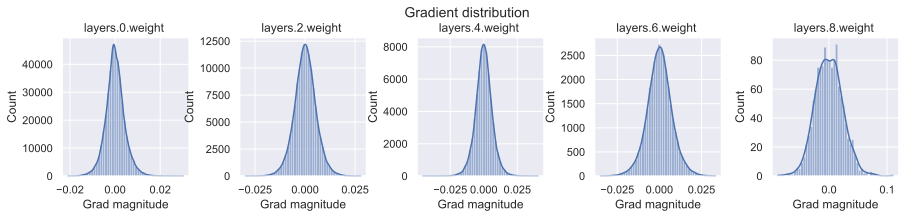

layers.0.weight - Variance: 1.7886630303109996e-05
layers.2.weight - Variance: 2.9344411814236082e-05
layers.4.weight - Variance: 3.8298123399727046e-05
layers.6.weight - Variance: 5.46534574823454e-05
layers.8.weight - Variance: 0.000557597610168159


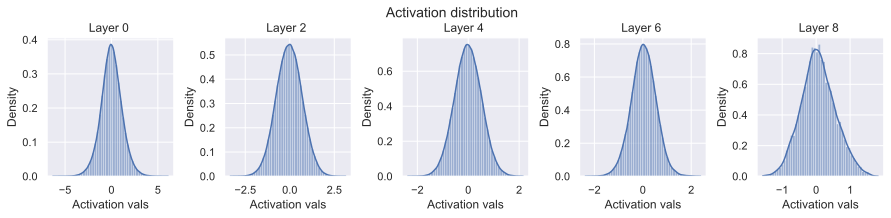

Layer 0 - Variance: 1.2717527151107788
Layer 2 - Variance: 0.5230247378349304
Layer 4 - Variance: 0.28064388036727905
Layer 6 - Variance: 0.2615452706813812
Layer 8 - Variance: 0.2561580538749695


In [43]:
model = BaseNetwork(act_fn=nn.Tanh()).to(device)
xavier_init(model)
visualize_gradients(model, print_variance=True)
visualize_activations(model, print_variance=True)

Although the variance decreases as the depth of the network increases, the activation distribution becomes more focused on the low values. We may conclude that **Xavier initialization** also works well for **tanh-based** networks.

What about ReLU-based network?

Note: we **can't assume that ReLU works as a linear function for small values** because it sets (in expectation) half of the inputs to 0 so that also the expectation of the input is not 0.

If we assume now that x is the output of a ReLU activation, we can calculate the expectation as follows:
<math xmlns="http://www.w3.org/1998/Math/MathML" display="block">
  <mtable displaystyle="true" columnalign="right" columnspacing="0em" rowspacing="3pt">
    <mtr>
      <mtd>
        <mtable displaystyle="true" columnalign="right left" columnspacing="0em" rowspacing="3pt">
          <mtr>
            <mtd>
              <mrow data-mjx-texclass="ORD">
                <mi mathvariant="double-struck">E</mi>
              </mrow>
              <mo stretchy="false">[</mo>
              <msup>
                <mi>x</mi>
                <mn>2</mn>
              </msup>
              <mo stretchy="false">]</mo>
            </mtd>
            <mtd>
              <mi></mi>
              <mo>=</mo>
              <mrow data-mjx-texclass="ORD">
                <mi mathvariant="double-struck">E</mi>
              </mrow>
              <mo stretchy="false">[</mo>
              <mo data-mjx-texclass="OP" movablelimits="true">max</mo>
              <mo stretchy="false">(</mo>
              <mn>0</mn>
              <mo>,</mo>
              <mrow data-mjx-texclass="ORD">
                <mover>
                  <mi>y</mi>
                  <mo stretchy="false">~</mo>
                </mover>
              </mrow>
              <msup>
                <mo stretchy="false">)</mo>
                <mn>2</mn>
              </msup>
              <mo stretchy="false">]</mo>
            </mtd>
          </mtr>
          <mtr>
            <mtd></mtd>
            <mtd>
              <mi></mi>
              <mo>=</mo>
              <mfrac>
                <mn>1</mn>
                <mn>2</mn>
              </mfrac>
              <mrow data-mjx-texclass="ORD">
                <mi mathvariant="double-struck">E</mi>
              </mrow>
              <mo stretchy="false">[</mo>
              <msup>
                <mrow data-mjx-texclass="ORD">
                  <mrow data-mjx-texclass="ORD">
                    <mover>
                      <mi>y</mi>
                      <mo stretchy="false">~</mo>
                    </mover>
                  </mrow>
                </mrow>
                <mn>2</mn>
              </msup>
              <mo stretchy="false">]</mo>
              <mspace width="2cm"></mspace>
              <mrow data-mjx-texclass="ORD">
                <mover>
                  <mi>y</mi>
                  <mo stretchy="false">~</mo>
                </mover>
              </mrow>
              <mtext>&#xA0;is zero-centered and symmetric</mtext>
            </mtd>
          </mtr>
          <mtr>
            <mtd></mtd>
            <mtd>
              <mi></mi>
              <mo>=</mo>
              <mfrac>
                <mn>1</mn>
                <mn>2</mn>
              </mfrac>
              <mtext>Var</mtext>
              <mo stretchy="false">(</mo>
              <mrow data-mjx-texclass="ORD">
                <mover>
                  <mi>y</mi>
                  <mo stretchy="false">~</mo>
                </mover>
              </mrow>
              <mo stretchy="false">)</mo>
            </mtd>
          </mtr>
        </mtable>
      </mtd>
    </mtr>
  </mtable>
</math>

Thus, we can see that there is an additional factor of 1/2 so the desired weight variance is <math xmlns="http://www.w3.org/1998/Math/MathML">
  <mn>2</mn>
  <mrow data-mjx-texclass="ORD">
    <mo>/</mo>
  </mrow>
  <msub>
    <mi>d</mi>
    <mi>x</mi>
  </msub>
</math>

This is the **Kaimiing initialization**.

Note that Kaiming initialization **does not use the harmonic mean between the input and output size**. In the original paper, they argue that using 
<math xmlns="http://www.w3.org/1998/Math/MathML">
  <msub>
    <mi>d</mi>
    <mi>x</mi>
  </msub>
</math>
or 
<math xmlns="http://www.w3.org/1998/Math/MathML">
  <msub>
    <mi>d</mi>
    <mi>y</mi>
  </msub>
</math>

**both lead to stable gradients** throughout the network, and **only depend on the overall input and output size** of the network. Thus, we can use only the input 
<math xmlns="http://www.w3.org/1998/Math/MathML">
  <msub>
    <mi>d</mi>
    <mi>x</mi>
  </msub>
</math>

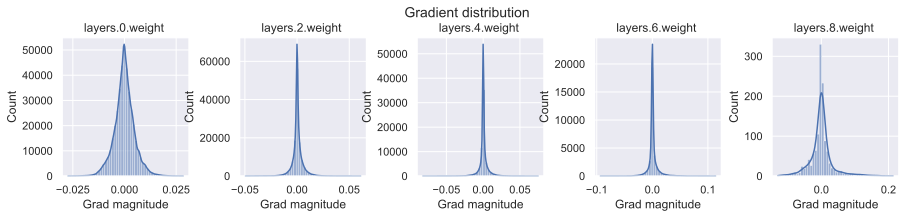

layers.0.weight - Variance: 2.38215179706458e-05
layers.2.weight - Variance: 2.6059486117446795e-05
layers.4.weight - Variance: 3.665043550427072e-05
layers.6.weight - Variance: 8.986311877379194e-05
layers.8.weight - Variance: 0.001282516517676413


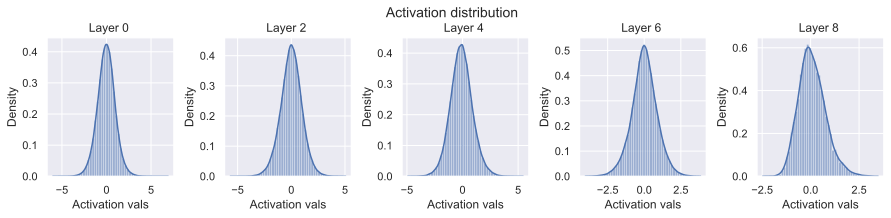

Layer 0 - Variance: 0.9944032430648804
Layer 2 - Variance: 0.9718494415283203
Layer 4 - Variance: 0.9832719564437866
Layer 6 - Variance: 0.7544287443161011
Layer 8 - Variance: 0.4834037721157074


In [44]:
def kaiming_init(model):
    for name, param in model.named_parameters():
        if name.endswith(".bias"):
            param.data.fill_(0)
        elif name.startswith("layers.0"): # The first layer does not have ReLU applied on its input
            param.data.normal_(0, 1/math.sqrt(param.shape[1]))
        else:
            param.data.normal_(0, math.sqrt(2)/math.sqrt(param.shape[1]))

model = BaseNetwork(act_fn=nn.ReLU()).to(device)
kaiming_init(model)
visualize_gradients(model, print_variance=True)
visualize_activations(model, print_variance=True)

The **variance stays stable** across layers.

We can conclude that **Kaiming initialization works well for ReLU-based networks**. Note that **for Leaky-ReLU etc**, we have to slightly **adjust the factor of 2 in the variance** as half of the values are not set to zero anymore.

PyTorch provides a function to **calculate this factor** for many activation functions, see **`torch.nn.init.calculate_gain`**


## Optimization

### Preparation

In [45]:
def _get_config_file(model_path, model_name):
    return os.path.join(model_path, model_name + ".config")

def _get_model_file(model_path, model_name):
    return os.path.join(model_path, model_name + ".tar")

def _get_result_file(model_path, model_name):
    return os.path.join(model_path, model_name + "_results.json")

def load_model(model_path, model_name, net=None):
    config_file, model_file = _get_config_file(model_path, model_name), _get_model_file(model_path, model_name)
    assert os.path.isfile(config_file), f"Could not find the config file \"{config_file}\". Are you sure this is the correct path and you have your model config stored here?"
    assert os.path.isfile(model_file), f"Could not find the model file \"{model_file}\". Are you sure this is the correct path and you have your model stored here?"

    with open(config_file, "r") as f:
        config_dict = json.load(f)

    if net is None:
        act_fn_name = config_dict['act_fn'].pop('name').lower()
        assert act_fn_name in act_fn_by_name, f"Unknown activation function \"{act_fn_name}\". Please add it to the \"act_fn_by_name\" dict."
        act_fn = act_fn_by_name[act_fn_name]()
        net = BaseNetwork(act_fn=act_fn, **config_dict)
    net.load_state_dict(torch.load(model_file))
    
    return net

def save_model(model, model_path, model_name):
    config_dict = model.config
    os.makedirs(model_path, exist_ok=True)
    config_file, model_file = _get_config_file(model_path, model_name), _get_model_file(model_path, model_name)
    
    with open(config_file, "w") as f:
        json.dump(config_dict, f)
    
    torch.save(model.state_dict(), model_file)

def train_model(net, model_name, optim_func, max_epochs=50, batch_size=256, overwrite=False):
    file_exists = os.path.isfile(_get_model_file(CHECKPOINT_PATH, model_name))
    if file_exists and not overwrite:
        print(f"Model file of \"{model_name}\" already exists. Skipping training...")
        with open(_get_result_file(CHECKPOINT_PATH, model_name), "r") as f:
            results = json.load(f)
    else:
        if file_exists:
            print("Model file exists, but will be overwritten...")

        optimizer = optim_func(net.parameters())
        loss_module = nn.CrossEntropyLoss()
        train_loader_local = data.DataLoader(train_set, batch_size=batch_size, shuffle=True, drop_last=True, pin_memory=True)
        results = None
        val_scores = []
        train_losses, train_scores = [], []
        best_val_epoch = -1

        for epoch in range(max_epochs):
            net.train()
            true_preds, count = 0., 0
            t = tqdm(train_loader_local, leave=False)
            
            for imgs, labels in t:
                imgs, labels = imgs.to(device), labels.to(device)
                optimizer.zero_grad()
                preds = net(imgs)
                loss = loss_module(preds, labels)
                loss.backward()
                optimizer.step()

                true_preds += (preds.argmax(dim=-1) == labels).sum().item()
                count += labels.shape[0]
                t.set_description(f"Epoch {epoch+1}: loss={loss.item():4.2f}")
                train_losses.append(loss.item())
            
            train_acc = true_preds / count
            train_scores.append(train_acc)

            # Validation
            val_acc = test_model(net, val_loader)
            val_scores.append(val_acc)
            print(f"[Epoch {epoch+1:2d}] Training accuracy: {train_acc*100.0:05.2f}%, Validation accuracy: {val_acc*100.0:05.2f}%")

            if len(val_scores) == 1 or val_acc > val_scores[best_val_epoch]:
                print("\t   (New best performance, saving model...)")
                save_model(net, CHECKPOINT_PATH, model_name)
                best_val_epoch = epoch


    if results is None:
        load_model(CHECKPOINT_PATH, model_name, net=net)
        test_acc = test_model(net, test_loader)
        results = {"test_acc": test_acc, "val_scores": val_scores, "train_losses": train_losses, "train_scores": train_scores}
        with open(_get_result_file(CHECKPOINT_PATH, model_name), "w") as f:
            json.dump(results, f)
    
    # Plot
    sns.set()
    plt.plot([i for i in range(1,len(results["train_scores"])+1)], results["train_scores"], label="Train")
    plt.plot([i for i in range(1,len(results["val_scores"])+1)], results["val_scores"], label="Val")
    plt.xlabel("Epochs")
    plt.ylabel("Validation accuracy")
    plt.ylim(min(results["val_scores"]), max(results["train_scores"])*1.01)
    plt.title(f"Validation performance of {model_name}")
    plt.legend()
    plt.show()
    plt.close()

    print((f" Test accuracy: {results['test_acc']*100.0:4.2f}% ").center(50, "=")+"\n")
    return results


def test_model(net, data_loader):
    net.eval()

    true_preds, count = 0., 0

    for imgs, labels in data_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        with torch.no_grad():
            preds = net(imgs).argmax(dim=-1)
            true_preds += (preds == labels).sum().item()
            count += labels.shape[0]

    test_acc = true_preds / count
    return test_acc

An **optimizer** is for **updating the model parameters** based on the given gradients.

An additional parameter is **learning rate** to **control the step size** of the update.

In [59]:
# Optimizer template function

class OptimizerTemplate:

    def __init__(self, params, lr):
        self.params = list(params)
        self.lr = lr

    def zero_grad(self):
        ## Set gradients of all parameters to zero
        for p in self.params:
            if p.grad is not None:
                p.grad.detach_() # For second-order optimizers important
                p.grad.zero_()

    @torch.no_grad()
    def step(self):
        ## Apply update step to all parameters
        for p in self.params:
            if p.grad is None: # We skip parameters without any gradients
                continue
            self.update_param(p)

    def update_param(self, p):
        # To be implemented in optimizer-specific classes
        raise NotImplementedError

SGD(Stochastic Gradient Descent)

<math xmlns="http://www.w3.org/1998/Math/MathML" display="block">
  <mtable displaystyle="true" columnalign="right left" columnspacing="0em" rowspacing="3pt">
    <mtr>
      <mtd>
        <msup>
          <mi>w</mi>
          <mrow data-mjx-texclass="ORD">
            <mo stretchy="false">(</mo>
            <mi>t</mi>
            <mo stretchy="false">)</mo>
          </mrow>
        </msup>
      </mtd>
      <mtd>
        <mi></mi>
        <mo>=</mo>
        <msup>
          <mi>w</mi>
          <mrow data-mjx-texclass="ORD">
            <mo stretchy="false">(</mo>
            <mi>t</mi>
            <mo>&#x2212;</mo>
            <mn>1</mn>
            <mo stretchy="false">)</mo>
          </mrow>
        </msup>
        <mo>&#x2212;</mo>
        <mi>&#x3B7;</mi>
        <mo>&#x22C5;</mo>
        <msup>
          <mi>g</mi>
          <mrow data-mjx-texclass="ORD">
            <mo stretchy="false">(</mo>
            <mi>t</mi>
            <mo stretchy="false">)</mo>
          </mrow>
        </msup>
      </mtd>
    </mtr>
  </mtable>
</math>

In [71]:
class SGD(OptimizerTemplate):

    def __init__(self, params, lr):
        super().__init__(params, lr)

    def update_param(self, p):
        p_update = -self.lr * p.grad
        p.add_(p_update) # In-place update => saves memory and does not create computation graph

SGD Momentum.

The momentum replaces the gradients by an exponential average of all past gradients(including the current one):

<math xmlns="http://www.w3.org/1998/Math/MathML" display="block">
  <mtable displaystyle="true" columnalign="right" columnspacing="0em" rowspacing="3pt">
    <mtr>
      <mtd>
        <mtable displaystyle="true" columnalign="right left" columnspacing="0em" rowspacing="3pt">
          <mtr>
            <mtd>
              <msup>
                <mi>m</mi>
                <mrow data-mjx-texclass="ORD">
                  <mo stretchy="false">(</mo>
                  <mi>t</mi>
                  <mo stretchy="false">)</mo>
                </mrow>
              </msup>
            </mtd>
            <mtd>
              <mi></mi>
              <mo>=</mo>
              <msub>
                <mi>&#x3B2;</mi>
                <mn>1</mn>
              </msub>
              <msup>
                <mi>m</mi>
                <mrow data-mjx-texclass="ORD">
                  <mo stretchy="false">(</mo>
                  <mi>t</mi>
                  <mo>&#x2212;</mo>
                  <mn>1</mn>
                  <mo stretchy="false">)</mo>
                </mrow>
              </msup>
              <mo>+</mo>
              <mo stretchy="false">(</mo>
              <mn>1</mn>
              <mo>&#x2212;</mo>
              <msub>
                <mi>&#x3B2;</mi>
                <mn>1</mn>
              </msub>
              <mo stretchy="false">)</mo>
              <mo>&#x22C5;</mo>
              <msup>
                <mi>g</mi>
                <mrow data-mjx-texclass="ORD">
                  <mo stretchy="false">(</mo>
                  <mi>t</mi>
                  <mo stretchy="false">)</mo>
                </mrow>
              </msup>
            </mtd>
          </mtr>
          <mtr>
            <mtd>
              <msup>
                <mi>w</mi>
                <mrow data-mjx-texclass="ORD">
                  <mo stretchy="false">(</mo>
                  <mi>t</mi>
                  <mo stretchy="false">)</mo>
                </mrow>
              </msup>
            </mtd>
            <mtd>
              <mi></mi>
              <mo>=</mo>
              <msup>
                <mi>w</mi>
                <mrow data-mjx-texclass="ORD">
                  <mo stretchy="false">(</mo>
                  <mi>t</mi>
                  <mo>&#x2212;</mo>
                  <mn>1</mn>
                  <mo stretchy="false">)</mo>
                </mrow>
              </msup>
              <mo>&#x2212;</mo>
              <mi>&#x3B7;</mi>
              <mo>&#x22C5;</mo>
              <msup>
                <mi>m</mi>
                <mrow data-mjx-texclass="ORD">
                  <mo stretchy="false">(</mo>
                  <mi>t</mi>
                  <mo stretchy="false">)</mo>
                </mrow>
              </msup>
            </mtd>
          </mtr>
        </mtable>
      </mtd>
    </mtr>
  </mtable>
</math>

In [72]:
class SGDMomentum(OptimizerTemplate):

    def __init__(self, params, lr, momentum=0.0):
        super().__init__(params, lr)
        self.momentum = momentum # Corresponds to beta_1 in the equation above
        self.param_momentum = {p: torch.zeros_like(p.data) for p in self.params} # Dict to store m_t

    def update_param(self, p):
        self.param_momentum[p] = (1 - self.momentum) * p.grad + self.momentum * self.param_momentum[p]
        p_update = -self.lr * self.param_momentum[p]
        p.add_(p_update)

Adam.

Adam combines the idea of momentum with an adaptive learning rate, which is based on an exponential average of the squared gradients, i.e. the gradients norm. Furthermore, add a bias correction to the first iterations.

<math xmlns="http://www.w3.org/1998/Math/MathML" display="block">
  <mtable displaystyle="true" columnalign="right" columnspacing="0em" rowspacing="3pt">
    <mtr>
      <mtd>
        <mtable displaystyle="true" columnalign="right left" columnspacing="0em" rowspacing="3pt">
          <mtr>
            <mtd>
              <msup>
                <mi>m</mi>
                <mrow data-mjx-texclass="ORD">
                  <mo stretchy="false">(</mo>
                  <mi>t</mi>
                  <mo stretchy="false">)</mo>
                </mrow>
              </msup>
            </mtd>
            <mtd>
              <mi></mi>
              <mo>=</mo>
              <msub>
                <mi>&#x3B2;</mi>
                <mn>1</mn>
              </msub>
              <msup>
                <mi>m</mi>
                <mrow data-mjx-texclass="ORD">
                  <mo stretchy="false">(</mo>
                  <mi>t</mi>
                  <mo>&#x2212;</mo>
                  <mn>1</mn>
                  <mo stretchy="false">)</mo>
                </mrow>
              </msup>
              <mo>+</mo>
              <mo stretchy="false">(</mo>
              <mn>1</mn>
              <mo>&#x2212;</mo>
              <msub>
                <mi>&#x3B2;</mi>
                <mn>1</mn>
              </msub>
              <mo stretchy="false">)</mo>
              <mo>&#x22C5;</mo>
              <msup>
                <mi>g</mi>
                <mrow data-mjx-texclass="ORD">
                  <mo stretchy="false">(</mo>
                  <mi>t</mi>
                  <mo stretchy="false">)</mo>
                </mrow>
              </msup>
            </mtd>
          </mtr>
          <mtr>
            <mtd>
              <msup>
                <mi>v</mi>
                <mrow data-mjx-texclass="ORD">
                  <mo stretchy="false">(</mo>
                  <mi>t</mi>
                  <mo stretchy="false">)</mo>
                </mrow>
              </msup>
            </mtd>
            <mtd>
              <mi></mi>
              <mo>=</mo>
              <msub>
                <mi>&#x3B2;</mi>
                <mn>2</mn>
              </msub>
              <msup>
                <mi>v</mi>
                <mrow data-mjx-texclass="ORD">
                  <mo stretchy="false">(</mo>
                  <mi>t</mi>
                  <mo>&#x2212;</mo>
                  <mn>1</mn>
                  <mo stretchy="false">)</mo>
                </mrow>
              </msup>
              <mo>+</mo>
              <mo stretchy="false">(</mo>
              <mn>1</mn>
              <mo>&#x2212;</mo>
              <msub>
                <mi>&#x3B2;</mi>
                <mn>2</mn>
              </msub>
              <mo stretchy="false">)</mo>
              <mo>&#x22C5;</mo>
              <msup>
                <mrow data-mjx-texclass="INNER">
                  <mo data-mjx-texclass="OPEN">(</mo>
                  <msup>
                    <mi>g</mi>
                    <mrow data-mjx-texclass="ORD">
                      <mo stretchy="false">(</mo>
                      <mi>t</mi>
                      <mo stretchy="false">)</mo>
                    </mrow>
                  </msup>
                  <mo data-mjx-texclass="CLOSE">)</mo>
                </mrow>
                <mn>2</mn>
              </msup>
            </mtd>
          </mtr>
          <mtr>
            <mtd>
              <msup>
                <mrow data-mjx-texclass="ORD">
                  <mover>
                    <mi>m</mi>
                    <mo stretchy="false">^</mo>
                  </mover>
                </mrow>
                <mrow data-mjx-texclass="ORD">
                  <mo stretchy="false">(</mo>
                  <mi>t</mi>
                  <mo stretchy="false">)</mo>
                </mrow>
              </msup>
            </mtd>
            <mtd>
              <mi></mi>
              <mo>=</mo>
              <mfrac>
                <msup>
                  <mi>m</mi>
                  <mrow data-mjx-texclass="ORD">
                    <mo stretchy="false">(</mo>
                    <mi>t</mi>
                    <mo stretchy="false">)</mo>
                  </mrow>
                </msup>
                <mrow>
                  <mn>1</mn>
                  <mo>&#x2212;</mo>
                  <msubsup>
                    <mi>&#x3B2;</mi>
                    <mn>1</mn>
                    <mrow data-mjx-texclass="ORD">
                      <mi>t</mi>
                    </mrow>
                  </msubsup>
                </mrow>
              </mfrac>
              <mo>,</mo>
              <msup>
                <mrow data-mjx-texclass="ORD">
                  <mover>
                    <mi>v</mi>
                    <mo stretchy="false">^</mo>
                  </mover>
                </mrow>
                <mrow data-mjx-texclass="ORD">
                  <mo stretchy="false">(</mo>
                  <mi>t</mi>
                  <mo stretchy="false">)</mo>
                </mrow>
              </msup>
              <mo>=</mo>
              <mfrac>
                <msup>
                  <mi>v</mi>
                  <mrow data-mjx-texclass="ORD">
                    <mo stretchy="false">(</mo>
                    <mi>t</mi>
                    <mo stretchy="false">)</mo>
                  </mrow>
                </msup>
                <mrow>
                  <mn>1</mn>
                  <mo>&#x2212;</mo>
                  <msubsup>
                    <mi>&#x3B2;</mi>
                    <mn>2</mn>
                    <mrow data-mjx-texclass="ORD">
                      <mi>t</mi>
                    </mrow>
                  </msubsup>
                </mrow>
              </mfrac>
            </mtd>
          </mtr>
          <mtr>
            <mtd>
              <msup>
                <mi>w</mi>
                <mrow data-mjx-texclass="ORD">
                  <mo stretchy="false">(</mo>
                  <mi>t</mi>
                  <mo stretchy="false">)</mo>
                </mrow>
              </msup>
            </mtd>
            <mtd>
              <mi></mi>
              <mo>=</mo>
              <msup>
                <mi>w</mi>
                <mrow data-mjx-texclass="ORD">
                  <mo stretchy="false">(</mo>
                  <mi>t</mi>
                  <mo>&#x2212;</mo>
                  <mn>1</mn>
                  <mo stretchy="false">)</mo>
                </mrow>
              </msup>
              <mo>&#x2212;</mo>
              <mfrac>
                <mi>&#x3B7;</mi>
                <mrow>
                  <msqrt>
                    <msup>
                      <mrow data-mjx-texclass="ORD">
                        <mover>
                          <mi>v</mi>
                          <mo stretchy="false">^</mo>
                        </mover>
                      </mrow>
                      <mrow data-mjx-texclass="ORD">
                        <mo stretchy="false">(</mo>
                        <mi>t</mi>
                        <mo stretchy="false">)</mo>
                      </mrow>
                    </msup>
                  </msqrt>
                  <mo>+</mo>
                  <mi>&#x3F5;</mi>
                </mrow>
              </mfrac>
              <mo>&#x2218;</mo>
              <msup>
                <mrow data-mjx-texclass="ORD">
                  <mover>
                    <mi>m</mi>
                    <mo stretchy="false">^</mo>
                  </mover>
                </mrow>
                <mrow data-mjx-texclass="ORD">
                  <mo stretchy="false">(</mo>
                  <mi>t</mi>
                  <mo stretchy="false">)</mo>
                </mrow>
              </msup>
            </mtd>
          </mtr>
        </mtable>
      </mtd>
    </mtr>
  </mtable>
</math>

Epsilon is a small constant to improve numerical stability for very small gradient norms.

Remember that the adaptive learning rate does not replace the learning rate hyperparameter but rather acts as an extra factor and ensures the gradients of various parameters have a similar norm.

In [73]:
class Adam(OptimizerTemplate):

    def __init__(self, params, lr, beta1=0.9, beta2=0.999, eps=1e-8):
        super().__init__(params, lr)
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.param_step = {p: 0 for p in self.params} # Remembers "t" for each parameter for bias correction
        self.param_momentum = {p: torch.zeros_like(p.data) for p in self.params}
        self.param_2nd_momentum = {p: torch.zeros_like(p.data) for p in self.params}

    def update_param(self, p):
        self.param_step[p] += 1

        self.param_momentum[p] = (1 - self.beta1) * p.grad + self.beta1 * self.param_momentum[p]
        self.param_2nd_momentum[p] = (1 - self.beta2) * (p.grad)**2 + self.beta2 * self.param_2nd_momentum[p]

        bias_correction_1 = 1 - self.beta1 ** self.param_step[p]
        bias_correction_2 = 1 - self.beta2 ** self.param_step[p]

        p_2nd_mom = self.param_2nd_momentum[p] / bias_correction_2
        p_mom = self.param_momentum[p] / bias_correction_1
        p_lr = self.lr / (torch.sqrt(p_2nd_mom) + self.eps)
        p_update = -p_lr * p_mom

        p.add_(p_update)

#### Comparing optimizers on model training

In [74]:
base_model = BaseNetwork(act_fn=nn.ReLU(), hidden_sizes=[512,256,256,128])
kaiming_init(base_model)

Model file of "FashionMNIST_SGD" already exists. Skipping training...


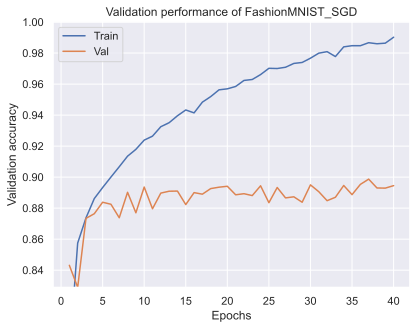

============= Test accuracy: 89.09% ==============



In [75]:
SGD_model = copy.deepcopy(base_model).to(device)
SGD_results = train_model(SGD_model, "FashionMNIST_SGD",
                          lambda params: SGD(params, lr=1e-1),
                          max_epochs=40, batch_size=256)

Model file of "FashionMNIST_SGDMom" already exists. Skipping training...


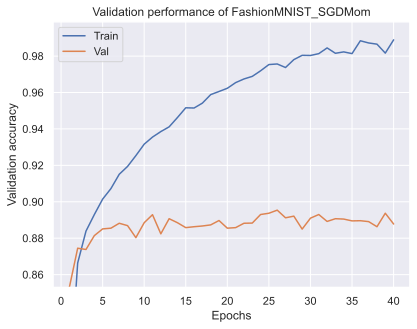

============= Test accuracy: 88.83% ==============



In [76]:
SGDMom_model = copy.deepcopy(base_model).to(device)
SGDMom_results = train_model(SGDMom_model, "FashionMNIST_SGDMom",
    lambda params: SGDMomentum(params, lr=1e-1, momentum=0.9),
    max_epochs=40, batch_size=256
)

Model file of "FashionMNIST_Adam" already exists. Skipping training...


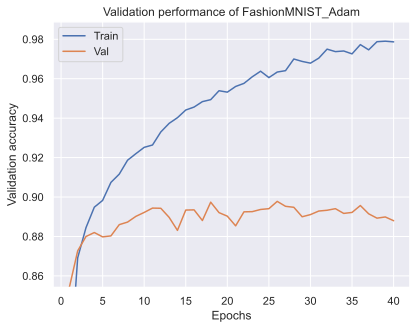

============= Test accuracy: 89.46% ==============



In [77]:
Adam_model = copy.deepcopy(base_model).to(device)
Adam_results = train_model(Adam_model, "FashionMNIST_Adam",
                           lambda params: Adam(params, lr=1e-3),
                           max_epochs=40, batch_size=256)

All optimizers perform similarly well with the given model. Keep in mind that this could be attribute to the kaiming initialization.

When the **initialization** techniques is **worse**(e.g. constant initialization), **Adam** usually shows to be **more robust** because of its adaptive learning rate.

#### Pathological curvatures

A **pathological curvatures** is a type of surface that similar to ravines and is particularly tricky for plain SGD optimization.

In words, pathological curvatures typically have **a steep gradient in one direction with an optimum at the center**, while in a second direction we have a slower gradient towards a (global) optimum. 

In [78]:
def pathological_curve_loss(w1, w2):
    x1_loss = torch.tanh(w1)**2 + 0.01 * torch.abs(w1)
    x2_loss = torch.sigmoid(w2)
    return x1_loss + x2_loss

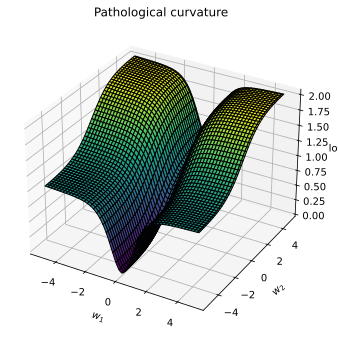

In [79]:
def plot_curve(curve_fn, x_range=(-5,5), y_range=(-5,5), plot_3d=False, cmap=cm.viridis, title="Pathological curvature"):
    fig = plt.figure()
    ax = plt.axes(projection='3d') if plot_3d else plt.axes()

    x = torch.arange(x_range[0], x_range[1], (x_range[1]-x_range[0])/100.)
    y = torch.arange(y_range[0], y_range[1], (y_range[1]-y_range[0])/100.)
    x, y = torch.meshgrid(x, y, indexing='xy')
    z = curve_fn(x, y)
    x, y, z = x.numpy(), y.numpy(), z.numpy()

    if plot_3d:
        ax.plot_surface(x, y, z, cmap=cmap, linewidth=1, color="#000", antialiased=False)
        ax.set_zlabel("loss")
    else:
        ax.imshow(z[::-1], cmap=cmap, extent=(x_range[0], x_range[1], y_range[0], y_range[1]))
    plt.title(title)
    ax.set_xlabel(r"$w_1$")
    ax.set_ylabel(r"$w_2$")
    plt.tight_layout()
    return ax

sns.reset_orig()
_ = plot_curve(pathological_curve_loss, plot_3d=True)
plt.show()

Note that in typical networks, we have many, many more parameters than two, and such curvatures can occur in multi-dimensional spaces as well.

In [80]:
def train_curve(optimizer_func, curve_func=pathological_curve_loss, num_updates=100, init=[5,5]):
    weights = nn.Parameter(torch.FloatTensor(init), requires_grad=True)
    optimizer = optimizer_func([weights])

    list_points = []
    for _ in range(num_updates):
        loss = curve_func(weights[0], weights[1])
        list_points.append(torch.cat([weights.data.detach(), loss.unsqueeze(dim=0).detach()], dim=0))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    points = torch.stack(list_points, dim=0).numpy()
    return points

Note that the learning rate is much higher than the usually because there are only 2 parameters to optimize rather than tens of thousands.

In [81]:
SGD_points = train_curve(lambda params: SGD(params, lr=10))
SGDMom_points = train_curve(lambda params: SGDMomentum(params, lr=10, momentum=0.9))
Adam_points = train_curve(lambda params: Adam(params, lr=1))

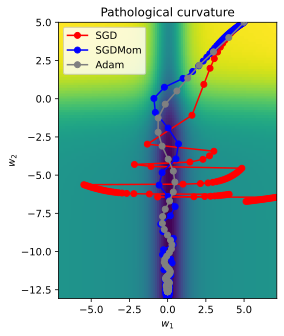

In [82]:
all_points = np.concatenate([SGD_points, SGDMom_points, Adam_points], axis=0)
ax = plot_curve(pathological_curve_loss,
                x_range=(-np.absolute(all_points[:,0]).max(), np.absolute(all_points[:,0]).max()),
                y_range=(all_points[:,1].min(), all_points[:,1].max()),
                plot_3d=False)
ax.plot(SGD_points[:,0], SGD_points[:,1], color="red", marker="o", zorder=1, label="SGD")
ax.plot(SGDMom_points[:,0], SGDMom_points[:,1], color="blue", marker="o", zorder=2, label="SGDMom")
ax.plot(Adam_points[:,0], Adam_points[:,1], color="grey", marker="o", zorder=3, label="Adam")
plt.legend()
plt.show()

On such surfaces, it is crucial to use momentum.

#### Steep optima

A second type of challenging loss surfaces are steep optima. In those, we have a larger part of the surface having very small gradients while around the optimum, we have very large gradients. For instance, take the following loss surfaces:

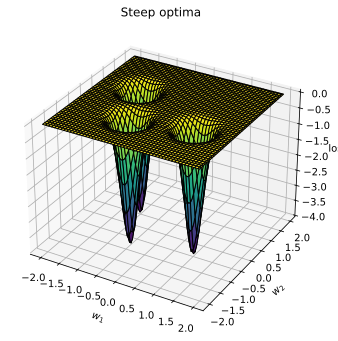

In [84]:
def bivar_gaussian(w1, w2, x_mean=0.0, y_mean=0.0, x_sig=1.0, y_sig=1.0):
    norm = 1 / (2 * np.pi * x_sig * y_sig)
    x_exp = (-1 * (w1 - x_mean)**2) / (2 * x_sig**2)
    y_exp = (-1 * (w2 - y_mean)**2) / (2 * y_sig**2)
    return norm * torch.exp(x_exp + y_exp)

def comb_func(w1, w2):
    z = -bivar_gaussian(w1, w2, x_mean=1.0, y_mean=-0.5, x_sig=0.2, y_sig=0.2)
    z -= bivar_gaussian(w1, w2, x_mean=-1.0, y_mean=0.5, x_sig=0.2, y_sig=0.2)
    z -= bivar_gaussian(w1, w2, x_mean=-0.5, y_mean=-0.8, x_sig=0.2, y_sig=0.2)
    return z

_ = plot_curve(comb_func, x_range=(-2,2), y_range=(-2,2), plot_3d=True, title="Steep optima")

Most of the loss surface has very little to no gradients. However, close to the optima, we have very steep gradients. To reach the minimum when starting in a region with lower gradients, we expect an adaptive learning rate to be crucial.

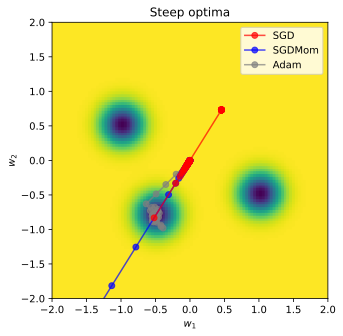

In [85]:
SGD_points = train_curve(lambda params: SGD(params, lr=.5), comb_func, init=[0,0])
SGDMom_points = train_curve(lambda params: SGDMomentum(params, lr=1, momentum=0.9), comb_func, init=[0,0])
Adam_points = train_curve(lambda params: Adam(params, lr=0.2), comb_func, init=[0,0])

all_points = np.concatenate([SGD_points, SGDMom_points, Adam_points], axis=0)
ax = plot_curve(comb_func,
                x_range=(-2, 2),
                y_range=(-2, 2),
                plot_3d=False,
                title="Steep optima")
ax.plot(SGD_points[:,0], SGD_points[:,1], color="red", marker="o", zorder=3, label="SGD", alpha=0.7)
ax.plot(SGDMom_points[:,0], SGDMom_points[:,1], color="blue", marker="o", zorder=2, label="SGDMom", alpha=0.7)
ax.plot(Adam_points[:,0], Adam_points[:,1], color="grey", marker="o", zorder=1, label="Adam", alpha=0.7)
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
plt.legend()
plt.show()


Adam is able to converge in the optimum showing the importance of adaptive learning rates.

#### What optimizer to take

Should we always use Adam and never look at SGD anymore? The short answer: **no**. 

There are many papers saying that in certain situations, SGD (with momentum) generalizes better where Adam often tends to overfit [5,6]. This is related to the idea of finding wider optima.

Finding sharp, narrow minima can be helpful for finding the minimal training loss. However, this doesn’t mean that it also minimizes the test loss as especially flat minima have shown to generalize better. You can imagine that the test dataset has a slightly shifted loss surface due to the different examples than in the training set. A small change can have a significant influence for sharp minima, while flat minima are generally more robust to this change.

Nevertheless, **Adam** is the **most commonly used** optimizer in **Deep Learning** as it usually performs better than other optimizers, especially for deep networks.